# 3 — Entrainement du modele de SIGNES-MOTS (sequences temporelles)

**Prerequis :** avoir lance `python download_signs_dataset.py` (dossier `data_signs/`).

Ce notebook passe au niveau superieur : un reseau **Conv1D + GRU** classe des **sequences** de landmarks (32 frames x 126 features, deux mains). L'evaluation utilise un **decoupage par participant** : le test ne contient que des signeurs jamais vus a l'entrainement — c'est donc directement un chiffre de **generalisation inter-personnes** (reponse a la critique du chiffre « en distribution » des lettres).

Sorties : `sign_words_model.h5` + `sign_words_labels.json` (a copier dans `asl_app/`).


In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

SEQ_LEN, FRAME_DIM = 32, 126
DATA = "data_signs"

# === IDENTIQUE a word_signs.py (toute divergence detruit la precision) ===
def _norm_hand(lm):
    h = lm.astype(np.float32).copy()
    h -= h[0]
    s = np.linalg.norm(h[9, :2])
    if s < 1e-6: s = 1e-6
    return (h / s).flatten()

def build_frame_features(left, right):
    l = _norm_hand(left) if left is not None else np.zeros(63, dtype=np.float32)
    r = _norm_hand(right) if right is not None else np.zeros(63, dtype=np.float32)
    return np.concatenate([l, r])

def resample_sequence(frames, n=SEQ_LEN):
    arr = np.asarray(frames, dtype=np.float32)
    if len(arr) == 0: return np.zeros((n, FRAME_DIM), dtype=np.float32)
    if len(arr) == 1: return np.repeat(arr, n, axis=0)
    src = np.linspace(0, len(arr) - 1, n)
    lo = np.floor(src).astype(int); hi = np.ceil(src).astype(int)
    w = (src - lo)[:, None]
    return (arr[lo] * (1 - w) + arr[hi] * w).astype(np.float32)


2026-07-08 12:09:42.806599: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-08 12:09:42.807592: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-08 12:09:42.823859: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-08 12:09:42.823875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-08 12:09:42.824376: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## 1. Chargement des sequences (parquet -> tenseurs)


In [2]:
def load_sequence(path):
    df = pd.read_parquet(path, columns=["frame", "type", "landmark_index", "x", "y", "z"])
    df = df[df["type"].isin(["left_hand", "right_hand"])]
    feats = []
    for _, g in df.groupby("frame"):
        hands = {}
        for t, gg in g.groupby("type"):
            arr = gg.sort_values("landmark_index")[["x", "y", "z"]].to_numpy(dtype=np.float32)
            if len(arr) == 21 and not np.isnan(arr).all():
                arr = np.nan_to_num(arr, nan=0.0)
                hands[t] = arr
        if hands:
            feats.append(build_frame_features(hands.get("left_hand"), hands.get("right_hand")))
    return feats

subset = pd.read_csv(os.path.join(DATA, "subset.csv"))
X_list, y_list, groups = [], [], []
skipped = 0
for row in subset.itertuples():
    p = os.path.join(DATA, "raw", f"{row.sequence_id}.parquet")
    if not os.path.exists(p):
        skipped += 1; continue
    frames = load_sequence(p)
    if len(frames) < 5:
        skipped += 1; continue
    X_list.append(resample_sequence(frames))
    y_list.append(row.sign)
    groups.append(row.participant_id)

X = np.stack(X_list); y = np.array(y_list); groups = np.array(groups)
labels = sorted(set(y))
y_idx = np.array([labels.index(s) for s in y])
print(f"{len(X)} sequences chargees ({skipped} ignorees) | {len(labels)} signes | {len(set(groups))} participants")


432 sequences chargees (1008 ignorees) | 9 signes | 21 participants


## 2. Decoupage PAR PARTICIPANT + augmentation temporelle

Le test ne contient que des signeurs jamais vus : le score mesure la **generalisation inter-personnes**.


In [3]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, te = next(gss.split(X, y_idx, groups))
X_tr, X_te, y_tr, y_te = X[tr], X[te], y_idx[tr], y_idx[te]
print("train:", len(X_tr), "| test (participants inconnus):", len(X_te))

def augment_seq(x):
    out = x.copy()
    # etirement temporel leger
    n = np.random.randint(int(SEQ_LEN*0.85), SEQ_LEN+1)
    out = resample_sequence(out[np.sort(np.random.choice(SEQ_LEN, n, replace=False))])
    # rotation xy par main + bruit
    theta = np.deg2rad(np.random.uniform(-12, 12))
    c_, s_ = np.cos(theta), np.sin(theta)
    R = np.array([[c_, -s_], [s_, c_]], dtype=np.float32)
    for off in (0, 63):
        h = out[:, off:off+63].reshape(SEQ_LEN, 21, 3)
        h[:, :, :2] = h[:, :, :2] @ R.T
        out[:, off:off+63] = h.reshape(SEQ_LEN, 63)
    out += np.random.normal(0, 0.02, out.shape).astype(np.float32)
    return out

def mirror_seq(x):
    out = x.copy().reshape(SEQ_LEN, 2, 21, 3)
    out = out[:, ::-1]                 # echange gauche/droite
    out[..., 0] *= -1                  # miroir x
    return out.reshape(SEQ_LEN, FRAME_DIM)

Xa = [X_tr] + [np.stack([augment_seq(x) for x in X_tr])] \
   + [np.stack([mirror_seq(x) for x in X_tr])] \
   + [np.stack([augment_seq(mirror_seq(x)) for x in X_tr])]
X_tr_a = np.concatenate(Xa)
y_tr_a = np.concatenate([y_tr] * len(Xa))
print("train apres augmentation :", X_tr_a.shape)


train: 330 | test (participants inconnus): 102
train apres augmentation : (1320, 32, 126)


## 3. Modele sequentiel Conv1D + GRU


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, FRAME_DIM)),
    layers.Conv1D(64, 5, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv1D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GRU(128, return_sequences=True),
    layers.GRU(64),
    layers.Dropout(0.35),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(len(labels), activation="softmax"),
])
model.compile(optimizer="adam", loss=SparseCategoricalCrossentropy(), metrics=["accuracy"])
model.summary()

cbs = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
       tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)]
hist = model.fit(X_tr_a, y_tr_a, validation_data=(X_te, y_te),
                 epochs=60, batch_size=64, callbacks=cbs, verbose=1)

model.save("sign_words_model.h5")
with open("sign_words_labels.json", "w") as f:
    json.dump(labels, f)
print("OK -> sign_words_model.h5 + sign_words_labels.json (a copier dans asl_app/)")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 32, 64)            40384     
                                                                 
 batch_normalization (Batch  (None, 32, 64)            256       
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 32, 128)           24704     
                                                                 
 batch_normalization_1 (Bat  (None, 32, 128)           512       
 chNormalization)                                                
                                                                 
 gru (GRU)                   (None, 32, 128)           99072     
                                                                 
 gru_1 (GRU)                 (None, 64)                3

/home/lamsn01/Sign-Language-Recognition-System/Sign_to_Sentence Project/streamlit/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 4. Evaluation inter-personnes


Precision INTER-PERSONNES : 75.49%  (participants jamais vus)

              precision    recall  f1-score   support

         bad       0.45      0.71      0.56         7
       drink       1.00      0.92      0.96        12
        fine       0.78      0.64      0.70        11
        food       0.76      1.00      0.87        13
          go       0.50      0.33      0.40         6
       happy       0.92      0.86      0.89        14
       hello       0.85      0.65      0.73        17
        home       1.00      0.75      0.86        12
       later       0.47      0.70      0.56        10

    accuracy                           0.75       102
   macro avg       0.75      0.73      0.72       102
weighted avg       0.79      0.75      0.76       102



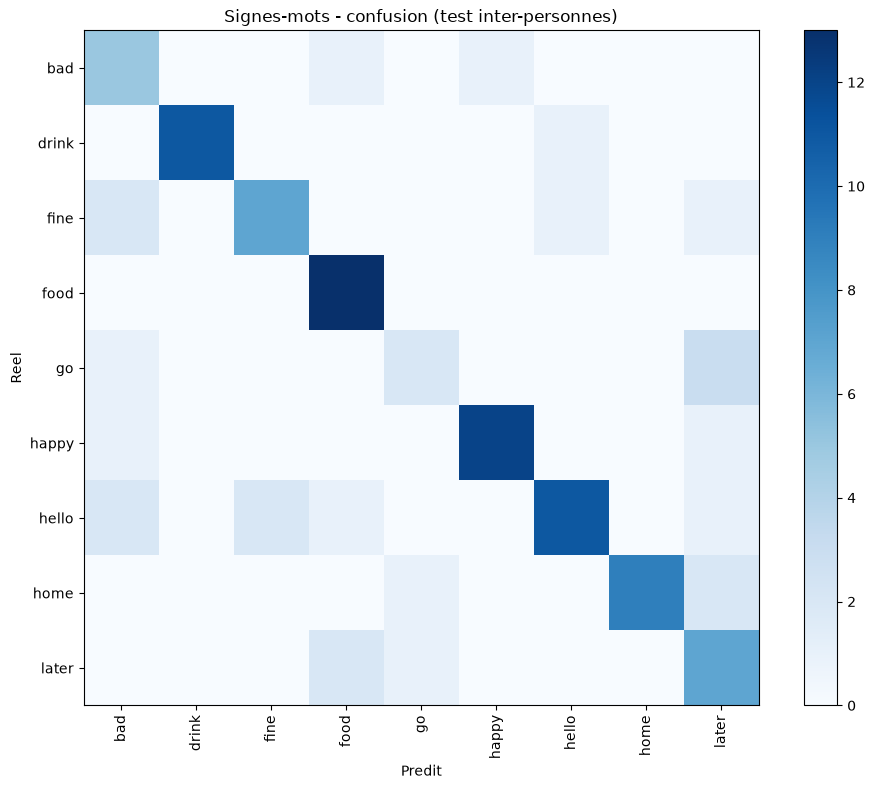

In [5]:
pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
acc = accuracy_score(y_te, pred)
print(f"Precision INTER-PERSONNES : {acc*100:.2f}%  (participants jamais vus)\n")
print(classification_report(y_te, pred, target_names=labels))

cm = confusion_matrix(y_te, pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predit"); plt.ylabel("Reel"); plt.title("Signes-mots - confusion (test inter-personnes)")
plt.tight_layout(); plt.show()
